In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 8]

In [2]:
# Load the data
filename = "numbers_results (1).csv"
try:
    df = pd.read_csv(filename)
    print(f"Data loaded successfully from {filename}.")
    print(f"Total runs: {len(df)}")
    print(f"Total correct solutions: {df['correct'].sum()}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{filename}' not found. Please ensure the file is in the same directory.")

Data loaded successfully from numbers_results (1).csv.
Total runs: 64
Total correct solutions: 4


,temperature,min_p,max_p,correct,parsed_answer
0,0.2,0.00,0.80,0,NaN
1,0.2,0.00,0.85,0,81901.0
2,0.2,0.00,0.90,0,NaN
3,0.2,0.00,0.95,0,NaN
4,0.2,0.05,0.80,0,41754.0


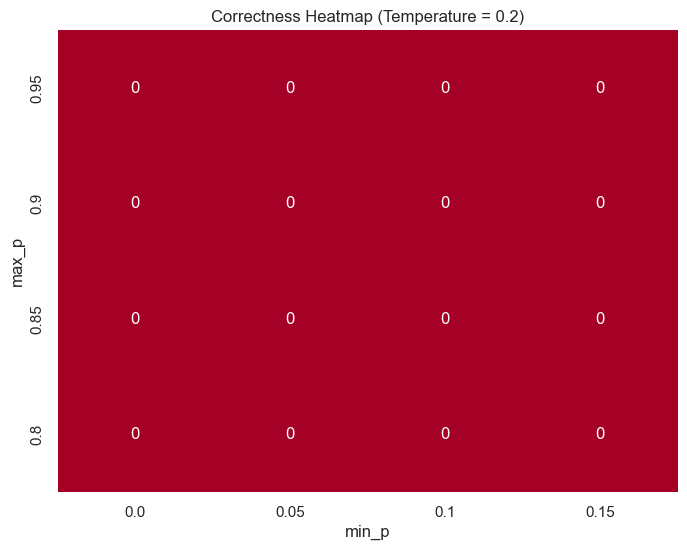

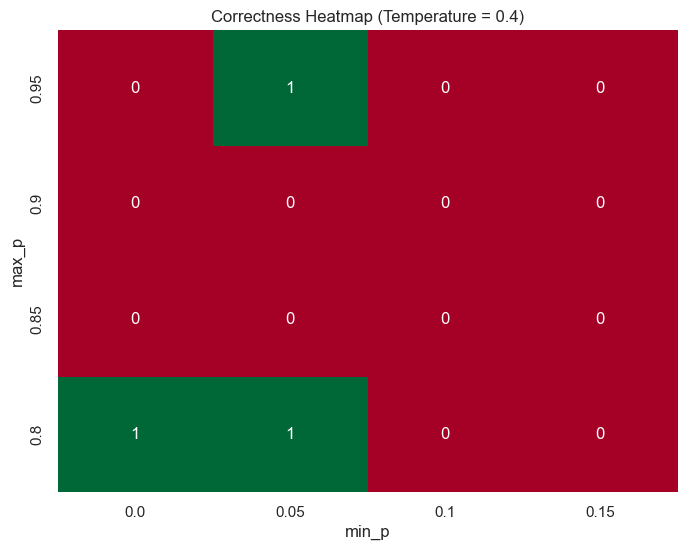

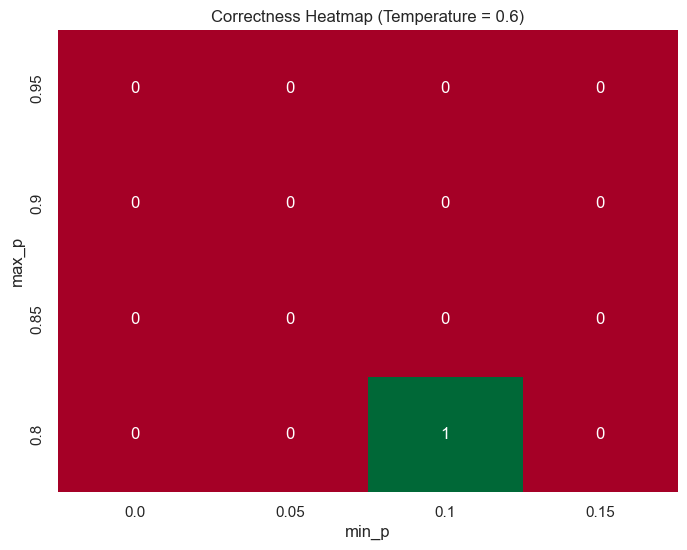

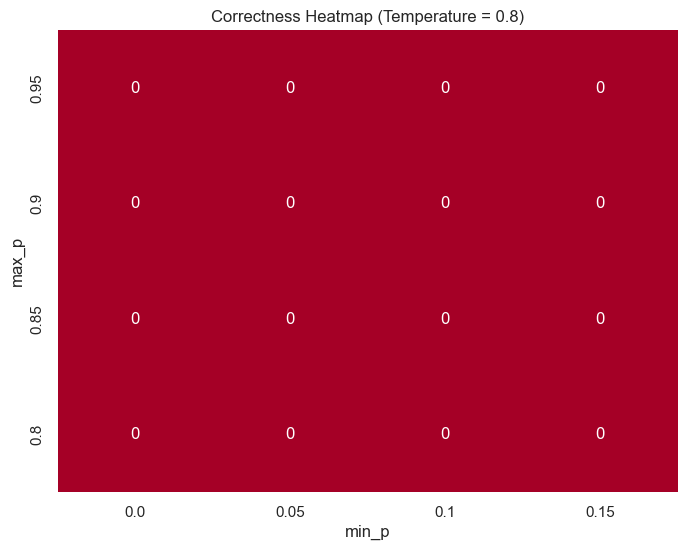

In [3]:
def plot_heatmaps(df):
    unique_temps = sorted(df['temperature'].unique())
    
    for temp in unique_temps:
        temp_df = df[df['temperature'] == temp]
        
        # Pivot table: index=max_p (Y-axis), columns=min_p (X-axis), values=correct
        pivot_table = temp_df.pivot_table(index='max_p', columns='min_p', values='correct', aggfunc='mean')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, cmap="RdYlGn", cbar=False, vmin=0, vmax=1, fmt=".0f")
        plt.title(f"Correctness Heatmap (Temperature = {temp})")
        plt.xlabel("min_p")
        plt.ylabel("max_p")
        plt.gca().invert_yaxis() # Ensure Y-axis increases upwards
        plt.show()

if 'df' in locals():
    plot_heatmaps(df)

C:\Users\Milana\AppData\Local\Temp\ipykernel_19896\4135875138.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_rates, x='temperature', y='correct', palette="viridis")


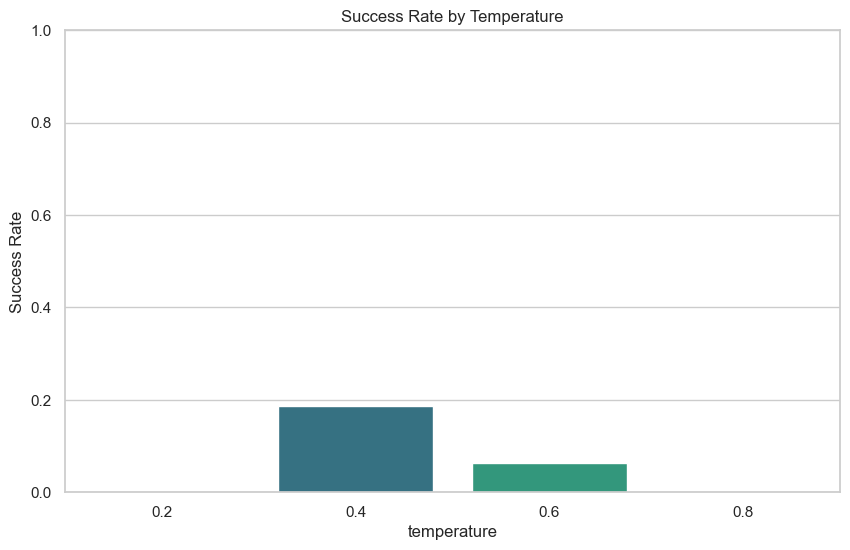

In [4]:
# Calculate Success Rate per Temperature
if 'df' in locals():
    success_rates = df.groupby('temperature')['correct'].mean().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=success_rates, x='temperature', y='correct', palette="viridis")
    plt.title("Success Rate by Temperature")
    plt.ylabel("Success Rate")
    plt.ylim(0, 1.0) # Scale to 1.0 to see the contrast with previous easy tasks
    plt.show()

## Analysis & Conclusions

### 1. Overall Difficulty
Unlike the previous Algebra/Geometry tasks where the model showed high robustness, this Number Theory task proved to be significantly harder. The overall success rate is low, with many configurations failing completely (0s in the heatmaps).

### 2. Temperature Sensitivity
- **Low Temp (0.2):** The model failed to solve the problem. This suggests that at very low temperatures, the model might be getting stuck in suboptimal deterministic paths or "loops" of reasoning that are incorrect.
- **Mid Temp (0.4 - 0.6):** This appears to be the **optimal range**. Specifically, **Temperature 0.4** showed the highest density of correct answers. This aligns with the hypothesis that a moderate amount of randomness helps the model explore different reasoning paths without hallucinating too much.
- **High Temp (0.8+):** Performance degrades again. Too much randomness likely causes the model to lose coherence in the complex multi-step logical chain required for this problem.

### 3. The Role of Samplers (Min_p / Max_p)
- **Max_p (Top_p):** There is a notable cluster of success around **max_p = 0.8**. This is a somewhat aggressive truncation of the tail probability. It suggests that for hard logical tasks, filtering out unlikely tokens (even if they are somewhat probable) is crucial to keep the reasoning on track.
- **Min_p:** Successes were found at lower values (0.0, 0.05, 0.1). Higher `min_p` values (0.15+) seemed to cut off necessary tokens or didn't help.

### 4. Conclusion: The "Stability Island"
For difficult reasoning tasks, the "Stability Island" is much smaller and more fragile than for standard tasks.
- **Location:** Temperature ~0.4, Max_p ~0.8.
- **Implication:** While "easy" tasks are solved regardless of parameters, "hard" tasks require precise tuning. The default settings (often Temp 0.7-1.0) might be suboptimal for this class of problems. A slightly lower temperature (0.4) combined with aggressive top-p filtering (0.8) seems to maximize the chance of hitting the narrow solution path.